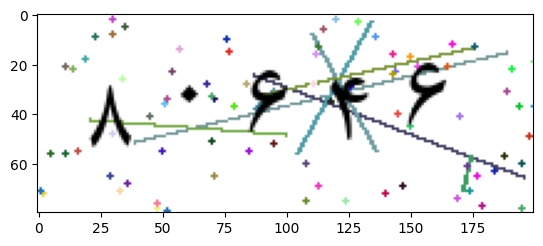

In [1]:
from PIL import Image
import matplotlib.pyplot as plt
image_path = "../data/captcha_generated/images/00005.png"
img = Image.open(image_path)
digits=[]
plt.imshow(img)

In [2]:
import cv2
import numpy as np


def preprocess(image_path):

    img = cv2.imread(image_path)

    # جدا کردن کانال‌ها
    b, g, r = cv2.split(img)

    # فقط پیکسل‌های نزدیک به سیاه را نگه دار
    mask = (
        (b < 20) &
        (g < 20) &
        (r < 20)
    )

    thresh = np.zeros_like(b)

    thresh[mask] = 255


    # حذف نویزهای خیلی کوچک
    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (1, 1)
    )

    thresh = cv2.morphologyEx(
        thresh,
        cv2.MORPH_OPEN,
        kernel
    )


    # کمی پر کردن شکستگی داخل اعداد
    thresh = cv2.morphologyEx(
        thresh,
        cv2.MORPH_CLOSE,
        kernel
    )

    return thresh

In [3]:
def find_digits(thresh):

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    boxes = []

    for contour in contours:

        x, y, w, h = cv2.boundingRect(contour)

        if h > 1 and w > 1:
            boxes.append((x,y,w,h))

    return sorted(
    boxes,
    key=lambda box: box[0]
)

In [4]:
def crop_digits(image_path, boxes, padding=8):

    img = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )

    digits = []

    height, width = img.shape


    for x, y, w, h in boxes:

        x1 = max(0, x - padding)
        y1 = max(0, y - padding)

        x2 = min(width, x + w + padding)
        y2 = min(height, y + h + padding)


        crop = img[y1:y2, x1:x2]

        digits.append(crop)


    return digits

(-0.5, 199.5, 79.5, -0.5)

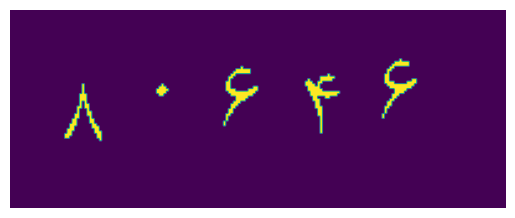

In [5]:
thresh = preprocess(image_path)
#thresh = cv2.cvtColor(thresh, cv2.COLOR_BGR2RGB)
plt.imshow(thresh)
plt.axis("off")

In [6]:
#test = cv2.cvtColor(thresh, cv2.COLOR_BGR2RGB)
#plt.imshow(test)

In [7]:
boxes = find_digits(thresh)

print(len(boxes))
print(boxes)

5
[(22, 30, 15, 23), (59, 30, 5, 5), (86, 23, 14, 24), (119, 26, 14, 24), (150, 20, 14, 24)]


(-0.5, 199.5, 79.5, -0.5)

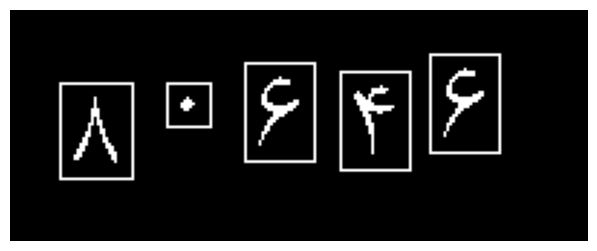

In [8]:
import cv2

img = thresh.copy()

for x,y,w,h in boxes:
    cv2.rectangle(
        img,
        (x-5,y-5),
        (x+w+5,y+h+5),
        (255,255,255),
        1
    )

plt.figure(figsize=(8,3))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

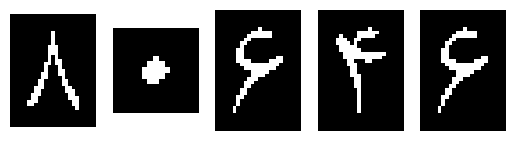

In [9]:
for i, (x,y,w,h) in enumerate(boxes):
    crop = thresh[y-5:y+h+5, x-5:x+w+5]
    digits.append(crop)
    plt.subplot(1,len(boxes),i+1)
    plt.imshow(crop,cmap="gray")
    plt.axis("off")

(-0.5, 199.5, 79.5, -0.5)

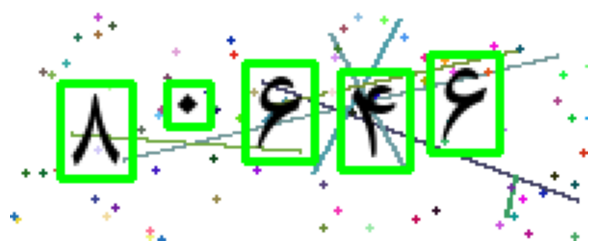

In [10]:
import cv2
import matplotlib.pyplot as plt


img = cv2.imread(image_path)

for x,y,w,h in boxes:
    cv2.rectangle(
        img,
        (x-5,y-5),
        (x+w+5,y+h+5),
        (0,255,0),
        2
    )


plt.figure(figsize=(8,3))
plt.imshow(
    cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
)
plt.axis("off")

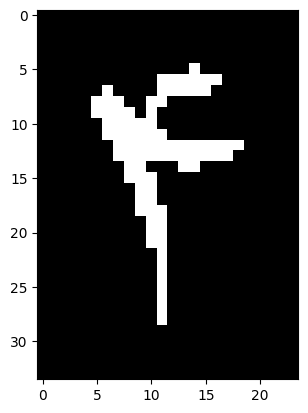

In [11]:
plt.imshow(digits[3], cmap="gray")